# Regresión Polinómica

¿Qué sucede si sus datos son más complejos que una línea recta? 

Sorprendentemente, puede usar un modelo lineal para ajustar datos no lineales. Una forma sencilla de hacerlo es agregar potencias de cada característica como nuevas características y luego entrenar un modelo lineal con este conjunto extendido de características. Esta técnica se denomina Regresión Polinómica.

Hay dos factores que determinan el rendimiento del modelo: sobreajuste y subajuste. El sobreajuste se produce cuando el modelo es demasiado complejo y funciona bien con los datos de entrenamiento, pero no con los de prueba. El subajuste se produce cuando el modelo es demasiado simple y funciona mal con los conjuntos de datos de entrenamiento y prueba.

El sobreajuste es fácil de abordar mediante métodos como la regularización, que analizaremos en el próximo laboratorio. Para abordar el subajuste, podemos construir un modelo más complejo utilizando métodos como la regresión polinómica. Si crear un modelo más complejo no funciona, puede ser necesario usar más datos para entrenar el modelo o para obtener nuevas características. Dado que este proceso es complejo, es mejor determinar primero si el modelo puede sobreajustar los datos. Por lo tanto, en esta sección, utilizaremos la regresión polinómica para sobreajustar los datos y determinar si contamos con una cantidad adecuada.

En este cuaderno, exploraremos la regresión polinómica y realizaremos transformaciones polinómicas utilizando características individuales y múltiples.

## Objetivos

Después de completar este laboratorio, podrá:

* Comprender el concepto de sobreajuste e infraajuste
* Aplicar transformaciones polinómicas a los datos
* Realizar una búsqueda de cuadrícula de hiperparámetros en un modelo, utilizando datos de validación

***


## **Setup**


En este laboratorio, utilizaremos las siguientes bibliotecas:
- [`pandas`](https://pandas.pydata.org/) para la gestión de datos.
- [`numpy`](https://numpy.org/) para operaciones matemáticas.
- [`seaborn`](https://seaborn.pydata.org/) para la visualización de datos.
- [`matplotlib`](https://matplotlib.org/) para la visualización de datos.
- [`sklearn`](https://scikit-learn.org/stable/) para funciones relacionadas con el aprendizaje automático y su canalización.
- [`scipy`](https://docs.scipy.org/doc/scipy/tutorial/stats.html/) para cálculos estadísticos.

## **Importar las bibliotecas necesarias**

Los siguientes módulos obligatorios están preinstalados en el entorno de Skills Network Labs. Sin embargo, si ejecuta estos comandos de notebook en un entorno Jupyter diferente (p. ej., Watson Studio o Anaconda), deberá instalar estas bibliotecas eliminando el símbolo "#" antes de "!mamba" en la celda de código a continuación.

In [1]:
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn


La siguiente función calculará el $R^{2}$ en cada característica dado un modelo de entrada.

In [2]:
def get_R2_features(model,test=True): 
    #X: global  
    features=list(X)
    features.remove("three")
    
    R_2_train=[]
    R_2_test=[]

    for feature in features:
        model.fit(X_train[[feature]],y_train)
        
        R_2_test.append(model.score(X_test[[feature]],y_test))
        R_2_train.append(model.score(X_train[[feature]],y_train))
        
    plt.bar(features,R_2_train,label="Train")
    plt.bar(features,R_2_test,label="Test")
    plt.xticks(rotation=90)
    plt.ylabel("$R^2$")
    plt.legend()
    plt.show()
    print("Training R^2 mean value {} Testing R^2 mean value {} ".format(str(np.mean(R_2_train)),str(np.mean(R_2_test))) )
    print("Training R^2 max value {} Testing R^2 max value {} ".format(str(np.max(R_2_train)),str(np.max(R_2_test))) )

La siguiente función graficará la distribución de dos entradas.

In [3]:
def  plot_dis(y,yhat):
    
    plt.figure()
    ax1 = sns.distplot(y, hist=False, color="r", label="Actual Value")
    sns.distplot(yhat, hist=False, color="b", label="Fitted Values" , ax=ax1)
    plt.legend()

    plt.title('Actual vs Fitted Values')
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')

    plt.show()
    plt.close()

## **Lectura y comprensión de nuestros datos**

Para este laboratorio, utilizaremos el conjunto de datos de ventas de automóviles, alojado en el almacenamiento de objetos de IBM Cloud. Este conjunto de datos también se puede encontrar y descargar desde [kaggle.com](https://www.kaggle.com/datasets/goyalshalini93/car-data), una fuente de datos pública y abierta.
El conjunto de datos contiene toda la información sobre los automóviles, el nombre del fabricante, todos los parámetros técnicos y el precio de venta.

Este conjunto de datos ya se ha depurado y codificado previamente (utilizando codificadores one-hot y de etiquetas) en el Cuaderno de Regresión Lineal.


Leamos los datos en el marco de datos de *pandas* y observemos las primeras 5 filas usando el método `head()`.

In [4]:
data = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/encoded_car_data.csv')
data.head()

,diesel,gas,std,turbo,convertible,hardtop,hatchback,sedan,wagon,4wd,...,wheelbase,curbweight,enginesize,boreratio,horsepower,carlength,carwidth,citympg,highwaympg,price
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,13495.0
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,16500.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,94.5,2823.0,152.0,2.68,154.0,171.2,65.5,19.0,26.0,16500.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,99.8,2337.0,109.0,3.19,102.0,176.6,66.2,24.0,30.0,13950.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,99.4,2824.0,136.0,3.19,115.0,176.6,66.4,18.0,22.0,17450.0


Podemos encontrar más información sobre las características y tipos utilizando el método `info()`.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diesel       205 non-null    float64
 1   gas          205 non-null    float64
 2   std          205 non-null    float64
 3   turbo        205 non-null    float64
 4   convertible  205 non-null    float64
 5   hardtop      205 non-null    float64
 6   hatchback    205 non-null    float64
 7   sedan        205 non-null    float64
 8   wagon        205 non-null    float64
 9   4wd          205 non-null    float64
 10  fwd          205 non-null    float64
 11  rwd          205 non-null    float64
 12  dohc         205 non-null    float64
 13  dohcv        205 non-null    float64
 14  l            205 non-null    float64
 15  ohc          205 non-null    float64
 16  ohcf         205 non-null    float64
 17  ohcv         205 non-null    float64
 18  rotor        205 non-null    float64
 19  eight   

Tenemos 35 características en nuestro conjunto de datos después de la codificación one-hot.

Antes de comenzar nuestro análisis polinomial, visualicemos algunas de las relaciones entre nuestras características y la variable objetivo, "precio".

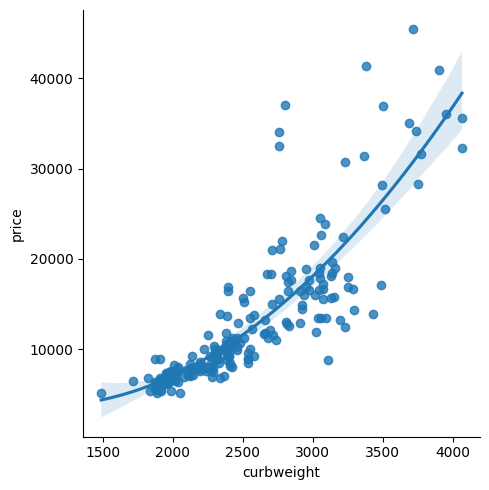

In [6]:
sns.lmplot(x = 'curbweight', y = 'price', data = data, order=2)

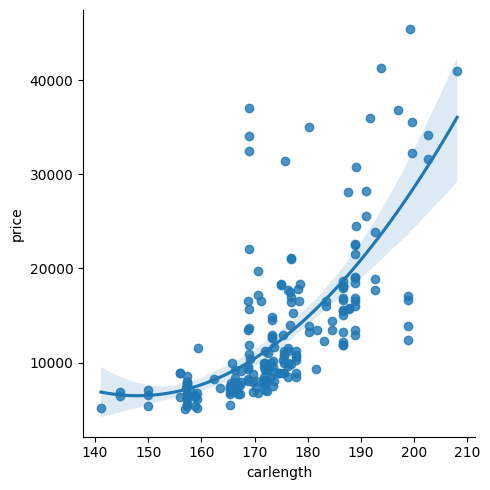

In [7]:
sns.lmplot(x = 'carlength', y = 'price', data = data, order=2)

La relación es más curva.

## Ejercicio 1
En este ejercicio, visualice la relación entre los "caballos de fuerza" y la variable objetivo, el "precio".

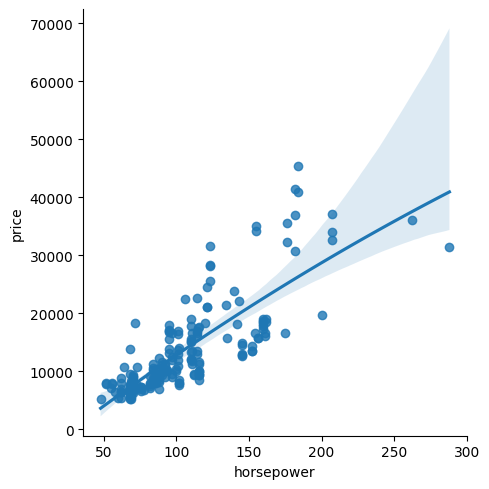

In [8]:
sns.lmplot(x = 'horsepower', y = 'price', data = data, order=2)

## Preparación de datos

Primero, dividamos nuestros datos en «X» características y «y» objetivo.

In [9]:
X = data.drop('price', axis=1)
y = data.price

## División de prueba del tren

Ahora que hemos dividido nuestros datos en conjuntos de entrenamiento y prueba, los datos de entrenamiento se utilizan para que su modelo reconozca patrones utilizando algunos criterios, y el conjunto de datos de prueba se utiliza para evaluar su modelo, como se muestra en la siguiente imagen:

<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/images/trin-test.png">
</center>
<center>source scikit-learn.org</center>


Ahora, dividimos nuestros datos, usando la función <code>train_test_split</code>, en los conjuntos de entrenamiento y prueba, asignando el 30% de los datos para las pruebas.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)
print("Number of test samples:", X_test.shape[0])
print("Number of training samples:", X_train.shape[0])


Number of test samples: 62
Number of training samples: 143


### Funciones múltiples

Creemos un objeto <code>LinearRegression</code>, llamado `lm`.

In [11]:
lm = LinearRegression()

Ahora, ajustemos el modelo con múltiples características en nuestros datos X_train e y_train.

In [12]:
lm.fit(X_train, y_train)

LinearRegression()

Aplicamos la función `predict(`) en el conjunto de datos de prueba.

In [13]:
predicted = lm.predict(X_test)

Calculemos el `r2_score()` en ambos conjuntos de datos, de entrenamiento y de prueba.

In [14]:
print("R^2 on training  data ",lm.score(X_train, y_train))
print("R^2 on testing data ",lm.score(X_test,y_test))

R^2 on training  data  0.9262116636455675
R^2 on testing data  0.8480759004420293


Podemos trazar distribuciones de los valores predichos versus los valores reales.

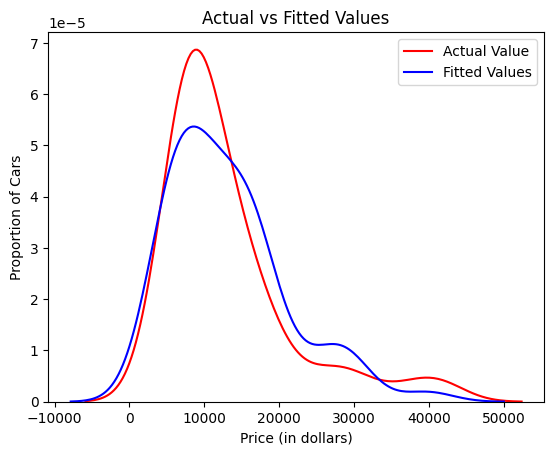

In [15]:
plot_dis(y_test,predicted)

A continuación, veremos los coeficientes estimados para el problema de regresión lineal.

In [16]:
{col:coef for col,coef in zip(X.columns, lm.coef_)}

{'diesel': 939008978272330.2,
 'gas': 939008978270851.4,
 'std': 311.1992298921475,
 'turbo': -312.55710010494,
 'convertible': 1742.6978434098812,
 'hardtop': 3124.2400859200447,
 'hatchback': -1762.4809942066847,
 'sedan': -651.6168263570904,
 'wagon': -2452.1431558297963,
 '4wd': -596.592401506275,
 'fwd': -340.71799641885275,
 'rwd': 936.8884443912425,
 'dohc': 2430.5246299110986,
 'dohcv': -13138.738424481147,
 'l': 2083.4823734072547,
 'ohc': 4602.7131348419625,
 'ohcf': 6030.002663855153,
 'ohcv': -2807.7834138242374,
 'rotor': 800.0614328429965,
 'eight': 9146.332312817596,
 'five': -2795.792677362974,
 'four': -5302.155726317422,
 'six': -2132.04872020696,
 'three': 0.0029296875,
 'twelve': 283.5355705887697,
 'two': 799.9994211242465,
 'wheelbase': 104.96903320384335,
 'curbweight': 4.797301430067242,
 'enginesize': 23.390802332787935,
 'boreratio': -1785.2794307982226,
 'horsepower': 68.4606429806709,
 'carlength': -64.47590836669504,
 'carwidth': 580.177012497484,
 'citympg

Como vemos, los dos primeros coeficientes son demasiado grandes para graficarlos, por lo que los descartaremos y graficaremos el resto de los coeficientes.

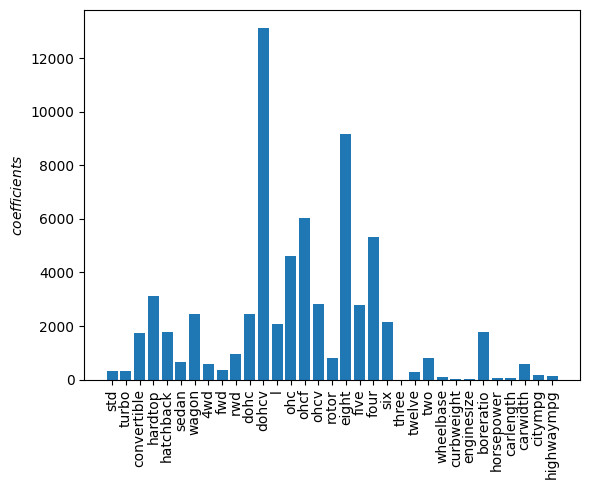

In [17]:
plt.bar(X.columns[2:],abs(lm.coef_[2:]))
plt.xticks(rotation=90)
plt.ylabel("$coefficients$")
plt.show()

Generalmente podemos interpretar que los coeficientes más grandes tienen mayor importancia en la predicción, pero este no siempre es el caso, así que veamos las características individuales.

### Características individuales

Podemos entrenar el modelo y trazar nuestro $R^2$ para cada una de las características en los conjuntos de datos de entrenamiento y prueba, utilizando la función <code>get_R2_features</code>.

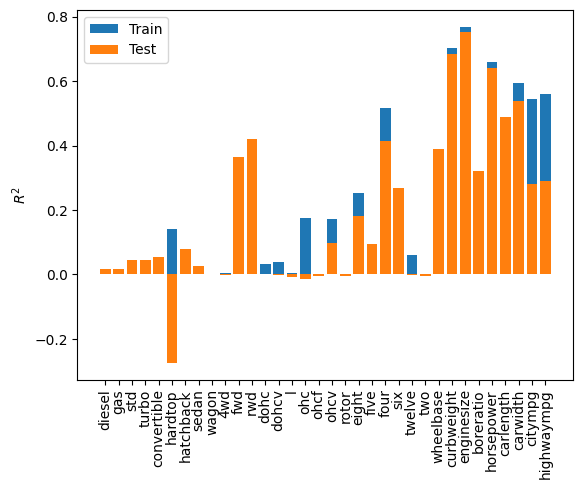

Training R^2 mean value 0.21817773426877918 Testing R^2 mean value 0.1824149303513925 
Training R^2 max value 0.7686929078033781 Testing R^2 max value 0.7534902447506852 


In [18]:
get_R2_features(lm)

En el gráfico anterior, vemos que algunas características individuales funcionan de manera similar al uso de todas las características (eliminamos la característica ```tres``` ), además, vemos que los coeficientes más pequeños parecen corresponder a un $R^{2}$ mayor, por lo tanto, los coeficientes más grandes corresponden a sobreajuste.

## Ejercicio 2
En este ejercicio, calcule el $R^2$ utilizando el objeto Pipeline para regresión lineal y aplique ```StandardScaler()``` a todas las características. Luego, utilice la función ```plot_dis``` para comparar los valores predichos con los valores reales.

R^2 on training  data  0.9262722224294516
R^2 on testing data  0.8419174509630338


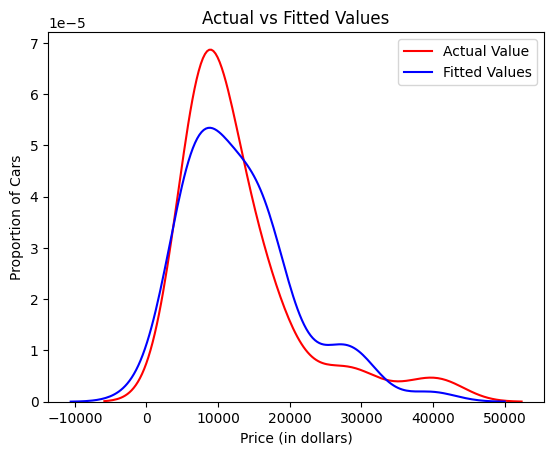

In [19]:
pipe = Pipeline([('ss',StandardScaler() ),('lr', LinearRegression())])
pipe.fit(X_train,y_train)
print("R^2 on training  data ", pipe.score(X_train, y_train))
print("R^2 on testing data ", pipe.score(X_test,y_test))
predicted = pipe.predict(X_test)
plot_dis(y_test,predicted)

## Ejercicio 3
En este ejercicio, calcule el $R^2$ utilizando el objeto Pipeline con ```StandardScaler()``` para cada característica individual usando la función ```get_R2_features```.

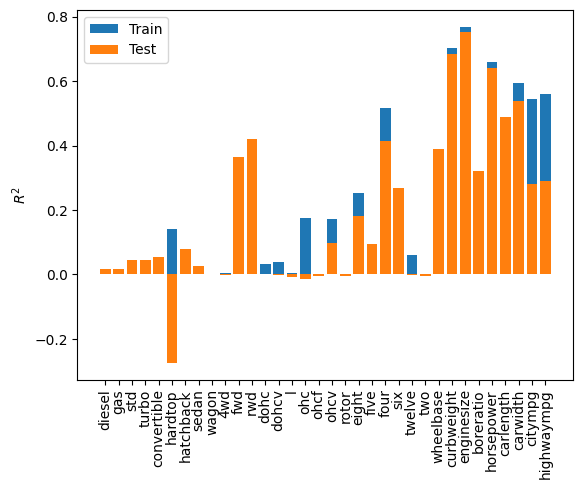

Training R^2 mean value 0.21817773426877918 Testing R^2 mean value 0.1824149303513925 
Training R^2 max value 0.7686929078033782 Testing R^2 max value 0.7534902447506853 


In [20]:
pipe = Pipeline([('ss',StandardScaler() ),('lr', LinearRegression())])
get_R2_features(pipe)

## Características polinómicas

### Funciones múltiples

La transformación polinómica es una forma sencilla de aumentar la complejidad del modelo, pero debemos tener cuidado con el sobrellenado.
A continuación, realizaremos una transformación polinómica de segundo grado (grado=2).

In [21]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)

Ahora, transformamos los conjuntos de datos de entrenamiento y prueba.

In [22]:
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

`X_train_poly` y `X_test_poly` ahora contienen las características originales de X, más el cuadrado de estas características y la combinación de términos cruzados.
Revisemos la forma de los conjuntos de entrenamiento y prueba recién creados.


In [23]:
print(X_train_poly.shape)

(143, 665)


In [24]:
print(X_test_poly.shape)

(62, 665)


En total, tenemos 665 características. Ahora, ajustamos el modelo con las características recién creadas.

In [25]:
lm = LinearRegression()
lm.fit(X_train_poly, y_train)

LinearRegression()

Y hacemos predicciones.

In [26]:
predicted = lm.predict(X_train_poly)

Nuevamente, podemos verificar el `r2 Score()` en ambos conjuntos de datos, de entrenamiento y de prueba.

In [27]:
print("R^2 on training data:", lm.score(X_train_poly, y_train))
print("R^2 on testing data:", lm.score(X_test_poly,y_test))

R^2 on training data: 0.9985318497975859
R^2 on testing data: -36729.95791737076


Vemos que el modelo tiene un $R^{2}$ negativo en el conjunto de datos de prueba, esto es una señal de sobreajuste.

### Características individuales

Las canalizaciones de datos simplifican el procesamiento de datos. Usamos el módulo <code>Pipeline</code> para crear una canalización. También usamos <code>PolynomialFeatures</code> como un paso en nuestra canalización.

In [28]:
Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model', LinearRegression())]

Podemos repetir los pasos anteriores, utilizando el objeto <code>Pipeline</code>.

In [29]:
pipe=Pipeline(Input)
pipe.fit(X_train, y_train)

Pipeline(steps=[('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

Podemos ver que los resultados son idénticos.

In [30]:
print("R^2 on training  data:", pipe.score(X_train, y_train))
print("R^2 on testing data:", pipe.score(X_test,y_test))

R^2 on training  data: 0.9985318497975859
R^2 on testing data: -36729.95791737076


Podemos entrenar nuestro modelo en cada una de las características usando la transformada de Característica Polinómica de segundo grado. Luego, podemos graficar nuestro $R^2$.

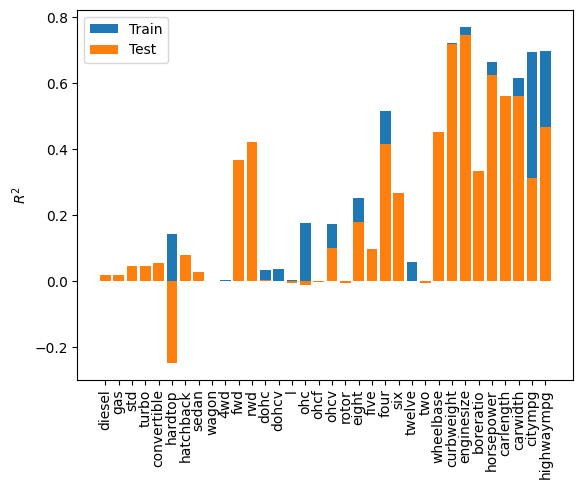

Training R^2 mean value 0.23076365436744212 Testing R^2 mean value 0.19470094530040022 
Training R^2 max value 0.7706959974452947 Testing R^2 max value 0.7463370080614307 


In [31]:
get_R2_features(pipe)

La característica con el $R^{2}$ máximo es mayor que cuando se utilizan todas las características.

## GridSearch y Pipeline


En esta sección del cuaderno, definiremos un objeto de canalización y luego usaremos GridSearch para encontrar los mejores hiperparámetros del modelo mediante el método de validación cruzada de la cuadrícula de parámetros, como se muestra en la figura a continuación. Por defecto, se utiliza una validación cruzada de 5 pasos. Aprenderemos más sobre la validación cruzada de k pasos en la siguiente lección del curso, "Validación cruzada".


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/images/k-fold.png">
</center>
<center>source scikit-learn.org</center>


Creamos el pipeline `PolynomialFeatures()`.

In [33]:
Input=[ ('scaler', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model',LinearRegression())]
pipe=Pipeline(Input)

Para buscar la mejor combinación de hiperparámetros, creamos un objeto <b>GridSearchCV</b> con un diccionario de valores de parámetros. Los parámetros de las canalizaciones se pueden configurar usando el nombre de la clave, separado por '__', y luego el nombre del parámetro de la clave.


In [34]:
param_grid = {
    "polynomial__degree": [1, 2, 3] 
}

<b>polynomial__degree</b>: es el grado del polinomio.

In [35]:
search = GridSearchCV(pipe, param_grid, n_jobs=1)

In [36]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [37]:
search.fit(X_test, y_test)

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('polynomial',
                                        PolynomialFeatures(include_bias=False)),
                                       ('model', LinearRegression())]),
             n_jobs=1, param_grid={'polynomial__degree': [1, 2, 3]})

El objeto encuentra los mejores valores de parámetros en los datos de validación. Podemos obtener el estimador con los mejores parámetros y asignarlo a la variable ```best```, como se indica a continuación:

In [38]:
best=search.best_estimator_
best

Pipeline(steps=[('scaler', StandardScaler()),
                ('polynomial',
                 PolynomialFeatures(degree=1, include_bias=False)),
                ('model', LinearRegression())])

Vemos que el grado es uno y la normalización es <code>Ture</code>.

Ahora, probamos nuestro modelo en los datos de prueba para ver la mejor puntuación.

In [39]:
best.score(X_test,y_test)

0.9663536494041001

Finalmente, podemos trazar una distribución de los valores predichos versus los valores reales.

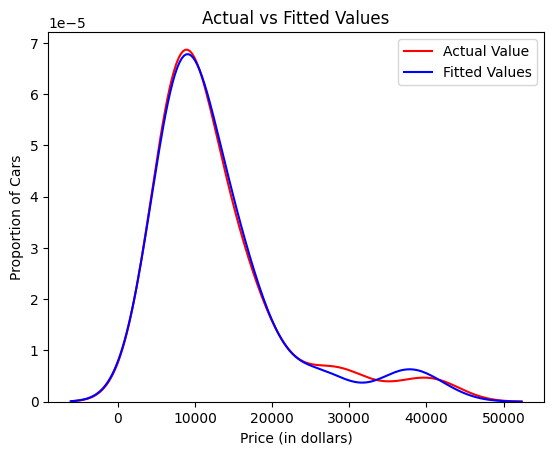

In [40]:
predicted=best.predict(X_test)
plot_dis(y_test,predicted)

¡Como vemos el resultado es casi perfecto!

## Ejercicio 4
En este ejercicio, calcule el $R^2$ utilizando el objeto ```Pipeline``` con ```GridSearch``` para cada entidad individual.

diesel
gas
std
turbo
convertible
hardtop
hatchback
sedan
wagon
4wd
fwd
rwd
dohc
dohcv
l
ohc
ohcf
ohcv
rotor
eight
five
four
six
three
twelve
two
wheelbase
curbweight
enginesize
boreratio
horsepower
carlength
carwidth
citympg
highwaympg


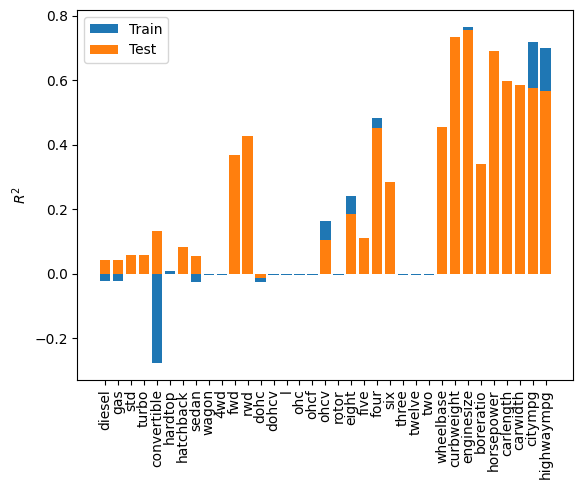

Training R^2 mean value 0.18271466517848528 Testing R^2 mean value 0.21980962661484352 
Training R^2 max value 0.7653236373791239 Testing R^2 max value 0.7565151400968062 


In [41]:
features=list(X)
   
    
R_2_train=[]
R_2_test=[]

for feature in features:
    param_grid = {
    "polynomial__degree": [ 1, 2,3,4,5],
    "model__positive":[True, False]}
    Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model',LinearRegression())]
    pipe=Pipeline(Input)
    print(feature)
    search = GridSearchCV(pipe, param_grid, n_jobs=2)
    search.fit(X_test[[feature]], y_test)
    best=search.best_estimator_
        
    R_2_test.append(best.score(X_test[[feature]],y_test))
    R_2_train.append(best.score(X_train[[feature]],y_train))
    
        
plt.bar(features,R_2_train,label="Train")
plt.bar(features,R_2_test,label="Test")
plt.xticks(rotation=90)
plt.ylabel("$R^2$")
plt.legend()
plt.show()
print("Training R^2 mean value {} Testing R^2 mean value {} ".format(str(np.mean(R_2_train)),str(np.mean(R_2_test))) )
print("Training R^2 max value {} Testing R^2 max value {} ".format(str(np.max(R_2_train)),str(np.max(R_2_test))) )


<!--| Date (YYYY-MM-DD) | Version | Changed By            | Change Description                   |
| ----------------- | ------- | --------------------- | ------------------------------------ |
|   2022-04-15      | 0.1     | Svitlana K.           | Created the first draft |
|   2022-04-18      | 0.1     | Joseph S.             | Updated all content |
|   2022-04-26      | 0.1     | Svitlana K.           | Corrected minor grammar errors |-->

